In [ ]:
!pip -q install -U \
    langchain \
    langchain-core \
    langchain-community \
    langchain-google-genai \
    langgraph \
    langchain-text-splitters \
    langchain-chroma \
    chromadb \
    sentence-transformers \
    langchain-huggingface \
    pypdf \
    mcp

In [ ]:
import os
import json
import sqlite3
import operator
import asyncio

from pathlib import Path
from typing import TypedDict, Annotated, Literal

print("Environment ready.")

Environment ready.


In [ ]:
import os
from getpass import getpass

# Ask for the API key only if it is not already available
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass(
        "Enter your Gemini API key: "
    )

print("Gemini API key loaded successfully.")
# AQ.Ab8RN6LCaVXPqsecx6yBSHZnoVn4fKZHdDkX-F7MlIJnVT6tzQ

Gemini API key loaded successfully.


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

print("Gemini LLM created.")

Gemini LLM created.


In [ ]:
response = llm.invoke(
    "What is an AI agent? Explain in 2 sentences."
)

print(response.content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'An AI agent is an autonomous software system that perceives its environment, makes decisions, and takes actions to achieve specific goals. By continuously learning and adapting from data, it can plan and execute complex tasks independently with minimal human intervention.', 'extras': {'signature': 'EsAWCr0WARFNMg9Mg916CqOeyzhreNmyHLscDG+HL9nfxkCBWS3nXr4+m3gX86IbwpEdVkxHUFjqK2kGOmRT20hUBAjEN9T3Qki3h/nLRDf+g78pToVZeRt2ytFSzsLOKQP8HJx7I4HqisidIa4CmQJ8tXKggDPlmNTTL0MIVg1dNVVrmUCthbCl5TVhKkba+MwuGSqfmekQP56Wd4zAhB0VC5VeIo0fxvGbyJOPaS7ZarOvQd0/0vNJuiMfQzOvZLxIKDcVPkfwUtLJnyGckp+AeDpz8xpnAe86Po4odKVulmVBT20IDYA7AH52P3PlGqTA3gq/oxe430hj/9TZ6CxxfZCbuLvP0jlD0vB+Y5t3tSGY0aIMIXSahxFt/cAqS67kYIk9ctvZ4EwGbXqFfyk1FYKHENjsq491Tf5P7uheq/bY0tk6CJGYY+dADWWOlEIxgkgdbsAIE4VfTa2/J0Ua8Bpi/A1jedLp4hwUy35xdWGqyv3of3JOI6qSl69p13Zyhxdonkym8652B2qVpMKl51Zk2bFSVmq/NNZwSpKJq0KyQeWGGolBKfhqXkkO+EuIHxSiu/1OHIiDYwQUno7UjZD91KJpHzgEtls6xBOQ0haGkH9jcUn5GgEu+64UbiZSDwTOeU23t4n364K9T3cad9qGKnZq2

In [ ]:
from langchain_core.tools import tool

@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

print(add.name)
print(add.description)

add
Add two numbers.


In [ ]:
result = add.invoke({
    "a": 10,
    "b": 20
})

print("Result:", result)

Result: 30.0


In [ ]:
@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b


@tool
def subtract(a: float, b: float) -> float:
    """Subtract b from a."""
    return a - b


@tool
def divide(a: float, b: float) -> float:
    """Divide a by b."""
    if b == 0:
        return "Error: cannot divide by zero."
    return a / b

In [ ]:
tools = [
    add,
    multiply,
    subtract,
    divide
]

for tool_obj in tools:
    print(
        f"{tool_obj.name} → {tool_obj.description}"
    )

add → Add two numbers.
multiply → Multiply two numbers.
subtract → Subtract b from a.
divide → Divide a by b.


In [ ]:
llm_with_tools = llm.bind_tools(tools)

print("LLM is now aware of the available tools.")

LLM is now aware of the available tools.


In [ ]:
response = llm_with_tools.invoke(
    "What is 25 multiplied by 16?"
)

print("CONTENT:")
print(response.content)

print("\nTOOL CALLS:")
print(response.tool_calls)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


CONTENT:
[]

TOOL CALLS:
[{'name': 'multiply', 'args': {'a': 25, 'b': 16}, 'id': 'call_954495', 'type': 'tool_call'}]


In [ ]:
tool_call = response.tool_calls[0]

tool_name = tool_call["name"]
tool_args = tool_call["args"]

print("Requested tool:", tool_name)
print("Arguments:", tool_args)

result = tools[1].invoke(tool_args)

print("Tool result:", result)

Requested tool: multiply
Arguments: {'a': 25, 'b': 16}
Tool result: 400.0


In [ ]:
tool_map = {
    tool_obj.name: tool_obj
    for tool_obj in tools
}

print(tool_map.keys())

dict_keys(['add', 'multiply', 'subtract', 'divide'])


In [ ]:
tool_map["multiply"]

StructuredTool(name='multiply', description='Multiply two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x79c06c215da0>)

In [ ]:
from langchain_core.messages import HumanMessage, ToolMessage

messages = [
    HumanMessage(
        content="What is twenty five multiplied by ten?"
    )
]

response = llm_with_tools.invoke(messages)

print("Tool calls:")
print(response.tool_calls)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool calls:
[{'name': 'multiply', 'args': {'b': 10, 'a': 25}, 'id': 'call_1268490', 'type': 'tool_call'}]


In [ ]:
messages.append(response)

for call in response.tool_calls:

    tool_name = call["name"]
    tool_args = call["args"]

    print("Executing:", tool_name)
    print("Arguments:", tool_args)

    result = tool_map[tool_name].invoke(tool_args)

    print("Result:", result)

    messages.append(
        ToolMessage(
            content=str(result),
            tool_call_id=call["id"]
        )
    )

Executing: multiply
Arguments: {'b': 10, 'a': 25}
Result: 250.0


In [ ]:
final_response = llm_with_tools.invoke(messages)

print(final_response.content)


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Twenty-five multiplied by ten is 250.', 'extras': {'signature': 'EroBCrcBARFNMg/C24HrMc77ZcUc9lEHMfZ1FLkZJY3QsQh3SwS9qftPS3AeAtHNvqO1jlsx/K/ytEvkmXnIp2CNRhjl8q2+PR75HY79398J7Cxc8ejmduMSnNsu52sinQmUwuG0xdpIJrYrGxdgxEckgC4+OWWc+iUBjFSYhFwOGyImmL4ff3tCYa5MbHsLAqnmQiC68YelyCik7HEa0Y8K8fF5+4HG6jlOrE12qut7cj8tLRujz+/5Th7y'}}]


1. User asks question
        ↓
2. LLM understands request
        ↓
3. LLM requests multiply()
        ↓
4. Python executes multiply()
        ↓
5. Python gets 400
        ↓
6. 400 is sent back to LLM
        ↓
7. LLM generates final answer

In [ ]:
def run_agent_loop(user_input, max_steps=5):

    messages = [
        HumanMessage(content=user_input)
    ]

    for step in range(max_steps):

        print(f"\n--- STEP {step + 1} ---")

        # Ask the LLM what to do
        response = llm_with_tools.invoke(messages)

        messages.append(response)

        # If no tool is requested,
        # the agent is finished.
        if not response.tool_calls:

            print("No tool required.")
            return response.content

        # Execute requested tools
        for call in response.tool_calls:

            tool_name = call["name"]
            tool_args = call["args"]

            print("Tool requested:", tool_name)
            print("Arguments:", tool_args)

            if tool_name not in tool_map:
                raise ValueError(
                    f"Tool {tool_name} is not allowed."
                )

            result = tool_map[tool_name].invoke(
                tool_args
            )

            print("Tool result:", result)

            messages.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=call["id"]
                )
            )

    return "Maximum agent steps reached."

In [ ]:
answer = run_agent_loop(
    "sum of 21 and 34?"
)

print("\nFINAL ANSWER:")
print(answer)


--- STEP 1 ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool requested: add
Arguments: {'b': 34, 'a': 21}
Tool result: 55.0

--- STEP 2 ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


No tool required.

FINAL ANSWER:
[{'type': 'text', 'text': 'The sum of 21 and 34 is 55.', 'extras': {'signature': 'Ep4BCpsBARFNMg/56qaCO1igCMrh4HO+2DYOBil+39WNIGh4KaxyX7zIuGgcEhVd/MFIM973qLP6li23z1io+gUmxrP5XpjwUoRC0yE7X7/OaKB6cwtmxXIZhzAxCNISzfrsQ2bsW9iRHboseJZu70jgysV5AoTTJaoZrGSZ02+T5khsazkUQJVspEhO2wCqnufuhXJjGL6NXI7oTDWUpEU='}}]


In [ ]:
answer = run_agent_loop(
    "product of 12 and 45 and then sum of 34?"
)

print("\nFINAL ANSWER:")
print(answer)


--- STEP 1 ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool requested: multiply
Arguments: {'b': 45, 'a': 12}
Tool result: 540.0

--- STEP 2 ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Tool requested: add
Arguments: {'b': 34, 'a': 540}
Tool result: 574.0

--- STEP 3 ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


GoogleRateLimitError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 18.613389524s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', '

In [ ]:
answer = run_agent_loop(
    "Explain what an AI agent is in simple terms."
)

print("\nFINAL ANSWER:")
print(answer)


--- STEP 1 ---


/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


No tool required.

FINAL ANSWER:
[{'type': 'text', 'text': 'An **AI agent** is an artificial intelligence program designed to perceive its environment, make decisions, and take actions to achieve a specific goal—often automatically and without needing constant human instructions.\n\nThink of an AI agent like a **smart digital assistant with a specific job**:\n\n1. **Perceives (Senses):** It gathers information from its surroundings (like reading text, looking at images, or listening to audio).\n2. **Decides (Thinks):** It analyzes that information using AI models or rules to figure out the best next step to reach its goal.\n3. **Acts (Does):** It performs an action based on its decision (like sending an email, adjusting a smart thermostat, or calling a tool/API to perform a calculation).\n4. **Learns & Adapts:** Many agents observe the results of their actions to improve their future decisions.\n\n---\n\n### Simple Everyday Examples:\n\n* **Smart Thermostat (e.g., Nest):** It senses th

                   USER
                     |
                     ↓
                   AGENT
                     |
                     ↓
                    LLM
                     |
            ┌────────┴────────┐
            ↓                 ↓
        Tool needed?          NO
            |                 |
           YES                ↓
            ↓             FINAL ANSWER
       Tool Selection
            ↓
       Tool Execution
            ↓
        Tool Result
            |
            └────────→ LLM

13.1 First understand the graph concept

A LangGraph workflow is made from:

State → information flowing through the workflow
Nodes → functions that perform work
Edges → define what happens next
START → beginning
END → completion

In [ ]:
from langgraph.graph import StateGraph, START, END

print("LangGraph imported successfully.")

LangGraph imported successfully.


Code 13.2 — Define State

Remember from the slides:

State is the information carried through the workflow.

Let's create a very simple state.

In [ ]:
from typing import TypedDict

class MyState(TypedDict):
    name: str

Code 13.3 — Create a Node

A node is a function that does some work.

In [ ]:
def greet(state: MyState):

    print("Node received:", state)

    return {
        "name": "Hello " + state["name"]
    }

Code 13.4 — Create the Graph

In [ ]:
graph_builder = StateGraph(MyState)

graph_builder.add_node(
    "greet",
    greet
)

print("Node added to graph.")

Node added to graph.


Code 13.5 — Add START → Node

In [ ]:
graph_builder.add_edge(
    START,
    "greet"
)

print("START → greet")

START → greet


Code 13.6 — Add Node → END

In [ ]:
graph_builder.add_edge(
    "greet",
    END
)

print("greet → END")

greet → END


Code 13.7 — Compile the Graph

Before execution, we compile the graph.

In [ ]:
graph = graph_builder.compile()

print("Graph compiled successfully.")

Graph compiled successfully.


Code 13.8 — Execute the Graph

Now we actually run it.

In [ ]:
result = graph.invoke({
    "name": "Students"
})

print("Final state:")
print(result)

Node received: {'name': 'Students'}
Final state:
{'name': 'Hello Students'}


What just happened?

This is the complete LangGraph execution:

Input State
   
   
START
   
greet node
   
    state["name"] = Students
   
  
returns:
{
    "name": "Hello Students"
}

   
END

Why is this useful?

Our previous agent was basically:

LLM

Tool

LLM

Tool

LLM

        ┌──────────────┐
        │    Agent     │
        └──────┬───────┘
               |
               v
        ┌──────────────┐
        │ Need Tool?   │
        └──────┬───────┘
           YES | NO
               |
       ┌───────┴───────┐
       ↓               ↓
    Tools             END
       |
       ↓
     Agent

Step 14 — LangGraph Agent + Tools

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage

print("LangGraph agent components imported.")

LangGraph agent components imported.


Code 14.1 — Define Agent State

Our agent needs to carry the conversation

In [ ]:
from typing import Annotated
import operator

class AgentState(TypedDict):

    messages: Annotated[
        list[BaseMessage],
        operator.add
    ]

Code 14.2 — Create the Agent Node

In [ ]:
def agent_node(state: AgentState):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

Code 14.3 — Create Graph Builder

In [ ]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node(
    "agent",
    agent_node
)

graph_builder.add_node(
    "tools",
    ToolNode(tools)
)

print("Agent and Tools nodes created.")

Agent and Tools nodes created.


We now have:

│   Agent   │



│   Tools   │


Code 14.4 — Connect START → Agent

In [ ]:
graph_builder.add_edge(
    START,
    "agent"
)

In [ ]:
graph_builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END
    }
)

Code 14.5 — Conditional Routing

This is one of the most important LangGraph concepts.

After the agent runs, we need to ask:

Does the LLM want to call a tool?

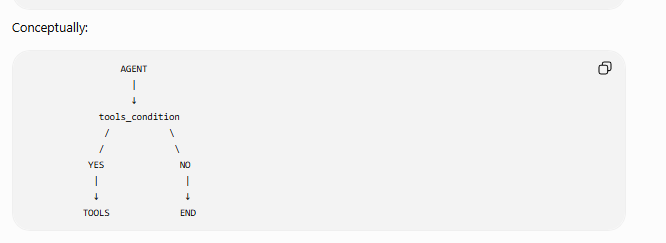

Code 14.6 — Tool → Agent
After the tool executes, we need to send its result back to the LLM.

In [ ]:
graph_builder.add_edge(
    "tools",
    "agent"
)

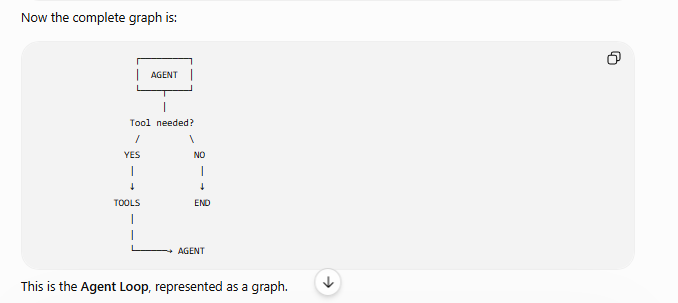

Code 14.7 — Compile

In [ ]:
agent_graph = graph_builder.compile()

print("Agent graph compiled.")

Agent graph compiled.


Code 14.8 — Run the Agent

In [ ]:
from langchain_core.messages import HumanMessage

result = agent_graph.invoke({
    "messages": [
        HumanMessage(
            content="What is 25 multiplied by 16?"
        )
    ]
})

print(result["messages"][-1].content)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': '25 multiplied by 16 is **400**.', 'extras': {'signature': 'EsoBCscBARFNMg/rG6vACPRl5z0P9XzV4ZMGen/dHJuXpb3CZTrIf/eumGGnqMDybZxE8HkCGiq4YL/b5FLC6RuOkg2I2pD979p1Otmh26Ecb4MIxUCK3phMyCxIyf2a0A95Q/I7367S+4v8FJNWPYr+nNNVZwlPRxH76AkKreTXerM2dH9VpJZUpUQuQPbXINoF2NozYMP/4hUZvGmsIhYiu0uDZbU1lTWQjXe+RkSgGwoM2DktUl27OAd36oS54UE4MfuMVkackg0itA=='}}]


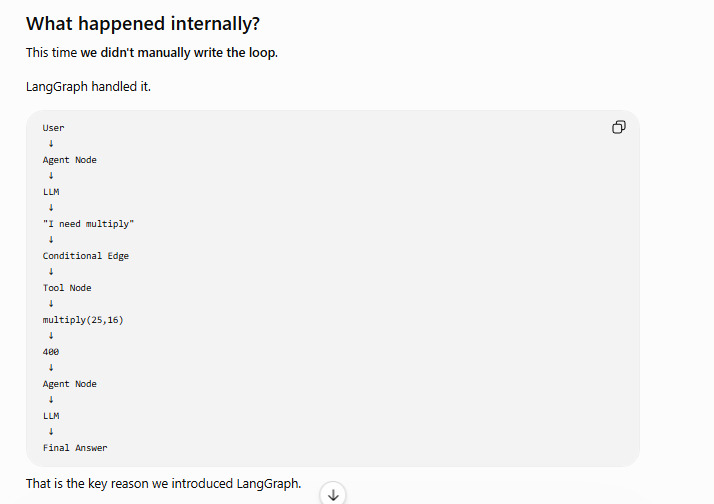

In [ ]:
!pip show mcp

Name: mcp
Version: 1.29.1
Summary: Model Context Protocol SDK
Home-page: https://modelcontextprotocol.io
Author: Anthropic, PBC.
Author-email: 
License: MIT
Location: /usr/local/lib/python3.13/dist-packages
Requires: anyio, httpx, httpx-sse, jsonschema, pydantic, pydantic-settings, pyjwt, python-multipart, sse-starlette, starlette, typing-extensions, typing-inspection, uvicorn
Required-by: 


In [ ]:
import mcp.client
import pkgutil

print("Available client modules:")
for x in pkgutil.iter_modules(mcp.client.__path__):
    print("-", x.name)

Available client modules:
- __main__
- auth
- experimental
- session
- session_group
- sse
- stdio
- streamable_http
- websocket


Step 1 — Create the MCP server

*This is we are doing on collab for only demo purpose

In [ ]:
!pip install 'mcp<2'

In [ ]:
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Student Tools")


@mcp.tool()
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b


@mcp.tool()
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b


print("MCP server created.")

MCP server created.


Step 2 — Ask the MCP server what tools it has

Your version exposes list_tools(), so we can use it directly:

In [ ]:
tools = await mcp.list_tools()

print("Available tools:")

for tool in tools:
    print("-", tool.name)

Available tools:
- add
- multiply


Step 3 — Call the MCP tool

Your FastMCP also exposes call_tool().

In [ ]:
result = await mcp.call_tool(
    "add",
    {
        "a": 10,
        "b": 20
    }
)

print("Result:", result)

Result: ([TextContent(type='text', text='30', annotations=None, meta=None)], {'result': 30})


In [ ]:
print(result)

([TextContent(type='text', text='30', annotations=None, meta=None)], {'result': 30})


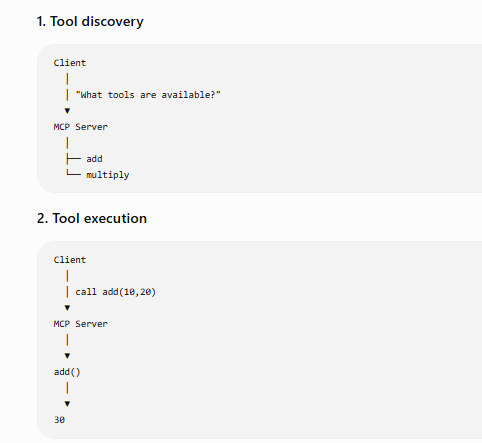

In [ ]:
from typing import TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END


# ---------- TOOLS ----------

@tool
def knowledge_search(topic: str) -> str:
    """Return basic knowledge about a technical topic."""

    knowledge = {
        "kubernetes": (
            "Kubernetes is a container orchestration platform. "
            "It manages containers, deployments, scaling, networking "
            "and service discovery."
        ),
        "docker": (
            "Docker packages applications and their dependencies "
            "into portable containers."
        ),
        "python": (
            "Python is a high-level programming language commonly "
            "used for automation, data science, AI and web development."
        )
    }

    return knowledge.get(
        topic.lower(),
        f"No knowledge found for {topic}."
    )


@tool
def study_plan(topic: str) -> str:
    """Create a simple study plan."""

    return f"""
3-Day Study Plan for {topic}

Day 1:
- Learn the fundamentals
- Understand key terminology

Day 2:
- Study architecture and components
- Practice small examples

Day 3:
- Build a mini project
- Solve practice questions
"""


tools = [knowledge_search, study_plan]


# ---------- STATE ----------

class StudyState(TypedDict):
    question: str
    topic: str
    route: str
    answer: str
    memory: str


print("Cell 1 complete.")

Cell 1 complete.


In [ ]:
def knowledge_agent(state: StudyState):

    topic = state["topic"]

    result = knowledge_search.invoke({
        "topic": topic
    })

    response = llm.invoke(
        f"""
You are the Knowledge Agent.

Topic: {topic}

Knowledge retrieved:
{result}

Explain this clearly to a beginner.
"""
    )

    return {
        "answer": get_text(response)
    }


def study_agent(state: StudyState):

    topic = state["topic"]

    plan = study_plan.invoke({
        "topic": topic
    })

    response = llm.invoke(
        f"""
You are the Study Planning Agent.

Topic: {topic}

Create a useful student-friendly study plan.

Suggested plan:
{plan}
"""
    )

    return {
        "answer": get_text(response)
    }


print("Agents fixed.")

Agents fixed.


In [ ]:
def get_text(response):
    """Convert Gemini response content into plain text."""

    content = response.content

    if isinstance(content, str):
        return content.strip()

    if isinstance(content, list):
        texts = []

        for block in content:
            if isinstance(block, str):
                texts.append(block)

            elif isinstance(block, dict) and "text" in block:
                texts.append(block["text"])

        return "".join(texts).strip()

    return str(content).strip()


def supervisor(state: StudyState):

    question = state["question"]

    response = llm.invoke(
        f"""
You are a supervisor for a Student Study Assistant.

Student question:
{question}

Choose exactly ONE route.

KNOWLEDGE
Use this for explanations, definitions and concepts.

STUDY
Use this for study plans, learning schedules and preparation.

Return ONLY one word:
KNOWLEDGE
or
STUDY
"""
    )

    route = get_text(response).upper()

    if "STUDY" in route:
        route = "STUDY"
    else:
        route = "KNOWLEDGE"

    return {
        "route": route
    }


def route_agent(state: StudyState):

    if state["route"] == "STUDY":
        return "study"

    return "knowledge"


print("Supervisor fixed.")

Supervisor fixed.


In [ ]:
builder = StateGraph(StudyState)

# Nodes
builder.add_node("supervisor", supervisor)
builder.add_node("knowledge", knowledge_agent)
builder.add_node("study", study_agent)

# Start
builder.add_edge(START, "supervisor")

# Supervisor routing
builder.add_conditional_edges(
    "supervisor",
    route_agent,
    {
        "knowledge": "knowledge",
        "study": "study"
    }
)

# Finish
builder.add_edge("knowledge", END)
builder.add_edge("study", END)

study_assistant = builder.compile()

print("Complete multi-agent graph created.")

Complete multi-agent graph created.


In [ ]:
# Test 1 — Knowledge question

result = study_assistant.invoke({
    "question": "What is Kubernetes?",
    "topic": "Kubernetes",
    "route": "",
    "answer": "",
    "memory": ""
})

print("QUESTION:")
print(result["question"])

print("\nROUTE:")
print(result["route"])

print("\nANSWER:")
print(result["answer"])

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


QUESTION:
What is Kubernetes?

ROUTE:
KNOWLEDGE

ANSWER:
Hello! As your Knowledge Agent, I'd be happy to break down **Kubernetes** into simple terms.

---

### What is Kubernetes?

Imagine a **container** as a lightweight, self-contained box that holds a piece of software and everything it needs to run. 

When you only have one or two containers, running them is easy. But what happens when you have hundreds or thousands of them working together for a popular app like Netflix or Spotify? Managing them manually becomes impossible.

**Kubernetes** (often called *K8s*) is the **ultimate manager or conductor** for all those containers. It automates the heavy lifting so developers don't have to manage every single container by hand.

---

### What Does Kubernetes Actually Do?

Based on its core capabilities, here is how Kubernetes works behind the scenes:

1. **Manages Containers (Health & Care)**
   * *What it means:* It keeps an eye on your containers 24/7. If a container crashes or gets s